# nbhood 官方数据对比

本 Notebook 读取 `test_data/official_test_nbhood/` 官方投影样例，经预处理写出 `cli_input/` 后运行迁移算法，并与 KGO、原 IMPROVER 输出对比。

**受原算法输入约束**：官方样例空间维为 `projection_x_coordinate` / `projection_y_coordinate` 且单位为米；插件内部不做投影转经纬或重网格。因此本 notebook 仅做**维名重命名**（投影维 → `lat`/`lon`，数值仍为米制投影坐标），不设「经纬重网格」第二套验证方案；KGO 与 `original_*.nc` 直接读取数据根目录下的官方投影 nc。

对比图包括：预处理输入、修改后算法、KGO、原算法输出。


## 环境准备

导入依赖、定位路径，并设置邻域半径与百分位参数。


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import BoundaryNorm, ListedColormap, TwoSlopeNorm

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PACKAGE_ROOT = Path.cwd().resolve().parent
PROJECT_DIR = PACKAGE_ROOT.parent
DATA_DIR = (PACKAGE_ROOT / "test_data" / "official_test_nbhood").resolve()
CLI_INPUT_DIR = DATA_DIR / "cli_input"
CLI_OUTPUT_DIR = DATA_DIR / "cli_output"

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from neighbourhood_probability_processing.src.nbhood import GeneratePercentilesFromANeighbourhood, NeighbourhoodProcessing

RADIUS_METRES = 20000.0
PERCENTILES = [25.0, 50.0, 75.0]
FILL_THRESHOLD = 1.0e20


d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 数据预处理

读官方投影 nc → 将 `projection_*` 重命名为 `lat/lon` → 构造六维 meb 网格 → 写出 `cli_input/`。

包含 `INPUT_JOBS` 中的常规样例，以及 `mask/input_masked.nc`（**内部掩码输入**）：以 `mask_and_scale=False` 读盘并**保留大填充值**，写出 `cli_input/mask/input_masked.nc`；算法侧通过 `MaskedArray` 路径识别内部掩码。


In [2]:
import json

PROB_VAR = "probability_of_thickness_of_rainfall_amount_above_threshold"
MASK_VAR = "land_binary_mask"
TEMP_VAR = "air_temperature"

MEMBER_LIKE_DIMS = ("member", "realization", "threshold", "number", "ensemble_member")

INPUT_JOBS = [

    ("basic", "input.nc", PROB_VAR),
    ("mask", "input.nc", PROB_VAR),
    ("mask", "mask.nc", MASK_VAR),
    ("percentile", "input_circular_percentile.nc", TEMP_VAR),
]


def load_primary_dataarray(
    nc_path: Path,
    var_name: str,
    *,
    mask_and_scale: bool = False,
) -> xr.DataArray:
    """读取 netCDF 主变量，并写入 grid_mapping_attrs。"""
    ds = xr.open_dataset(nc_path, decode_timedelta=False, mask_and_scale=mask_and_scale)
    try:
        if var_name not in ds.data_vars:
            raise ValueError(f"变量 {var_name} 不存在: {nc_path}")
        data = ds[var_name].load()
        grid_mapping_name = data.attrs.get("grid_mapping")
        if not isinstance(grid_mapping_name, str) or grid_mapping_name not in ds.variables:
            for other_name in ds.data_vars:
                cand = ds[other_name].attrs.get("grid_mapping")
                if isinstance(cand, str) and cand in ds.variables:
                    grid_mapping_name = cand
                    break
        if isinstance(grid_mapping_name, str) and grid_mapping_name in ds.variables:
            mapping_attrs_raw = dict(ds[grid_mapping_name].attrs)
            mapping_attrs_json_ready = {}
            for key, value in mapping_attrs_raw.items():
                if isinstance(value, np.ndarray):
                    mapping_attrs_json_ready[key] = value.tolist()
                elif isinstance(value, np.generic):
                    mapping_attrs_json_ready[key] = value.item()
                else:
                    mapping_attrs_json_ready[key] = value
            data.attrs["grid_mapping_attrs"] = json.dumps(
                mapping_attrs_json_ready, ensure_ascii=False
            )
        return data
    finally:
        ds.close()


def _extract_projected_spatial(da: xr.DataArray) -> xr.DataArray:
    """提取投影空间场；保留 member 语义维，将投影维重命名为 lat/lon。"""
    arr = da
    rename_map = {}
    if "projection_y_coordinate" in arr.dims:
        rename_map["projection_y_coordinate"] = "lat"
    if "projection_x_coordinate" in arr.dims:
        rename_map["projection_x_coordinate"] = "lon"
    if rename_map:
        arr = arr.rename(rename_map)
    keep_dims = set(MEMBER_LIKE_DIMS) | {"lat", "lon", "level"}
    for dim in list(arr.dims):
        if dim not in keep_dims:
            arr = arr.isel({dim: 0}, drop=True)
    member_dim = next((d for d in MEMBER_LIKE_DIMS if d in arr.dims), None)
    if member_dim is not None:
        return arr.transpose(member_dim, "lat", "lon")
    return arr.transpose("lat", "lon")


def _build_meb6d_from_spatial(spatial: xr.DataArray, *, name: str) -> xr.DataArray:
    """由 lat/lon 空间场构造六维 meb 网格。"""
    units = str(spatial.attrs.get("units", "1"))
    values = np.asarray(spatial.values, dtype=np.float32)
    member_dim = next((d for d in MEMBER_LIKE_DIMS if d in spatial.dims), None)

    if member_dim is not None:
        member_coord = np.asarray(spatial.coords[member_dim].values)
        if member_coord.dtype != object:
            member_coord = member_coord.astype(str)
        values_6d = values[:, np.newaxis, np.newaxis, np.newaxis, :, :].astype(np.float32)
    else:
        member_coord = np.array(["data0"], dtype=object)
        if values.ndim != 2:
            raise ValueError(f"期望二维空间场，当前 shape={values.shape}")
        values_6d = values[np.newaxis, np.newaxis, np.newaxis, np.newaxis, :, :].astype(np.float32)

    attrs = {
        "units": units,
        "model": "",
        "dtime_units": "hour",
        "level_type": "isobaric",
        "time_type": "UT",
        "time_bounds": [0, 0],
    }
    grid_mapping_attrs = spatial.attrs.get("grid_mapping_attrs")
    if isinstance(grid_mapping_attrs, str) and grid_mapping_attrs.strip():
        attrs["grid_mapping_attrs"] = grid_mapping_attrs

    return xr.DataArray(
        values_6d,
        dims=("member", "level", "time", "dtime", "lat", "lon"),
        coords={
            "member": member_coord,
            "level": np.array([0.0], dtype=np.float32),
            "time": np.array([np.datetime64("1970-01-01T00:00:00")], dtype="datetime64[ns]"),
            "dtime": np.array([0], dtype=np.int32),
            "lat": spatial.coords["lat"].copy(deep=True),
            "lon": spatial.coords["lon"].copy(deep=True),
        },
        attrs=attrs,
        name=name,
    )


def build_meb6d_from_projected(nc_path: Path, var_name: str) -> xr.DataArray:
    spatial = _extract_projected_spatial(load_primary_dataarray(nc_path, var_name))
    return _build_meb6d_from_spatial(spatial, name=var_name)


def build_internal_masked_meb6d_from_projected(nc_path: Path, var_name: str) -> xr.DataArray:
    """内部掩码输入：保留大填充值，供 MaskedArray 路径与 CLI 写出。"""
    spatial = _extract_projected_spatial(
        load_primary_dataarray(nc_path, var_name, mask_and_scale=False)
    )
    return _build_meb6d_from_spatial(spatial, name=var_name)


def save_meb6d_to_nc(data: xr.DataArray, dst_path: Path) -> None:
    normalized = data.copy(deep=True)
    normalized.attrs = {k: ("" if v is None else v) for k, v in dict(normalized.attrs).items()}
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    normalized.to_dataset(name=normalized.name).to_netcdf(dst_path)
    print(f"写出: {dst_path}")


cli_inputs = {
    (scenario, filename): build_meb6d_from_projected(DATA_DIR / scenario / filename, var_name)
    for scenario, filename, var_name in INPUT_JOBS
}
for (scenario, filename), data in cli_inputs.items():
    save_meb6d_to_nc(data, CLI_INPUT_DIR / scenario / filename)

basic_input = cli_inputs[("basic", "input.nc")]
mask_input = cli_inputs[("mask", "input.nc")]
mask_external = cli_inputs[("mask", "mask.nc")]
pct_input = cli_inputs[("percentile", "input_circular_percentile.nc")]

# 内部掩码仅用于算法层演示（MaskedArray 路径），不生成 CLI 版本：
# CLI 经 meb 读盘 + check_for_meb_griddata 会把大填充值夹成 NaN，无法承载内部掩码。
mask_internal_input = build_internal_masked_meb6d_from_projected(
    DATA_DIR / "mask" / "input_masked.nc",
    PROB_VAR,
)

print("预处理输入:", basic_input.dims, basic_input.shape)


写出: D:\workspace\improver\nbhood\test_data\official_test_nbhood\cli_input\basic\input.nc
写出: D:\workspace\improver\nbhood\test_data\official_test_nbhood\cli_input\mask\input.nc
写出: D:\workspace\improver\nbhood\test_data\official_test_nbhood\cli_input\mask\mask.nc
写出: D:\workspace\improver\nbhood\test_data\official_test_nbhood\cli_input\percentile\input_circular_percentile.nc
预处理输入: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (2, 1, 1, 1, 100, 100)


## 对比工具

绘图与 member 选择辅助函数。


In [3]:
def _detect_spatial_dims(da):
    for y_name, x_name in (
        ("lat", "lon"),
        ("latitude", "longitude"),
        ("projection_y_coordinate", "projection_x_coordinate"),
    ):
        if y_name in da.dims and x_name in da.dims:
            return y_name, x_name
    return da.dims[-2], da.dims[-1]


def to_plot_2d(da, member_index=0):
    if not isinstance(da, xr.DataArray):
        # MaskedArray 需保留掩码位（内部掩码 numpy 路径的无效格点靠 mask 表达）。
        arr = np.ma.asarray(da) if np.ma.isMaskedArray(da) else np.asarray(da)
        return arr.squeeze() if arr.ndim > 2 else arr
    work = da
    y_name, x_name = _detect_spatial_dims(work)
    if "member" in work.dims:
        work = work.isel(member=min(member_index, work.sizes["member"] - 1))
    indexers = {d: 0 for d in work.dims if d not in (y_name, x_name)}
    if indexers:
        work = work.isel(indexers)
    return np.asarray(work.values)


def member_groups_by_percentile(da):
    if not isinstance(da, xr.DataArray) or "member" not in da.dims:
        return {}
    key = next(
        (
            cand
            for cand in ("member_percentile", "percentile")
            if cand in da.coords and da.coords[cand].dims == ("member",)
        ),
        None,
    )
    if key is None:
        return {}
    groups = {}
    for i, v in enumerate(np.asarray(da.coords[key].values, dtype=np.float64)):
        groups.setdefault(float(v), []).append(i)
    return groups


def pick_member_by_percentile(da, percentile_value, prefer_realization_index=0):
    groups = member_groups_by_percentile(da)
    if not groups:
        return 0
    p = float(percentile_value)
    if p not in groups:
        return groups[sorted(groups.keys())[0]][0]
    candidates = groups[p]
    return int(candidates[min(prefer_realization_index, len(candidates) - 1)])


def to_percentile_2d(da, percentile_value, prefer_realization_index=0):
    """提取指定百分位的二维场，兼容堆叠 member 与 realization/percentile 维。"""
    if isinstance(da, xr.DataArray) and "percentile" in da.dims and "member" not in da.dims:
        work = da
        if "realization" in work.dims:
            rvals = np.asarray(work.coords["realization"].values)
            ridx = min(prefer_realization_index, len(rvals) - 1)
            work = work.sel(realization=rvals[ridx])
        work = work.sel(percentile=float(percentile_value), method="nearest")
        y_name, x_name = _detect_spatial_dims(work)
        return np.asarray(work.transpose(y_name, x_name).values)
    idx = pick_member_by_percentile(da, percentile_value, prefer_realization_index)
    return to_plot_2d(da, idx)


MEVA_INT32_FILL = -2147483648


def _restore_nan_from_mevadata_encoding(da: xr.DataArray) -> xr.DataArray:
    """将 meteva 写出时的 int32 填充值（× scale_factor）还原为 NaN。"""
    values = np.asarray(da.values, dtype=np.float64)
    invalid = ~np.isfinite(values) | (np.abs(values) >= FILL_THRESHOLD)
    # mask_and_scale=True 解码后 scale_factor 会从 attrs 移到 encoding，两处都要兜底。
    scale = da.attrs.get("scale_factor", da.encoding.get("scale_factor"))
    if scale is not None:
        scaled_fill = MEVA_INT32_FILL * float(scale)
        invalid |= np.isclose(values, scaled_fill, rtol=0.0, atol=1.0)
    cleaned = np.where(invalid, np.nan, values).astype(np.float32)
    out = da.copy(deep=True)
    out.values = cleaned.reshape(da.shape)
    return out


def load_cli_result_dataarray(path, var_name):
    """读取 meb CLI 写出的结果 nc，并将缺测哨兵还原为 NaN。"""
    da = load_primary_dataarray(path, var_name, mask_and_scale=True)
    return _restore_nan_from_mevadata_encoding(da)


def field_2d_for_compare(da, *, member_index=0):
    """将 CLI/插件结果压成可对比的二维场（兼容 threshold 投影输出）。"""
    work = da
    if isinstance(work, xr.DataArray) and "threshold" in work.dims:
        work = work.isel(threshold=min(member_index, work.sizes["threshold"] - 1))
    return masked_values(to_plot_2d(work, member_index))


def max_abs_diff_2d(a, b, member_index=0):
    left = np.ma.asarray(field_2d_for_compare(a, member_index=member_index))
    right = np.ma.asarray(field_2d_for_compare(b, member_index=member_index))
    return float(np.nanmax(np.abs(left - right)))


def mask_fill_values_array(data, fill_threshold=FILL_THRESHOLD):
    """将大填充值转为 MaskedArray（算法内部掩码路径）。"""
    values = np.asarray(
        data.values if isinstance(data, xr.DataArray) else data,
        dtype=np.float32,
    )
    masked = np.ma.masked_invalid(values)
    return np.ma.masked_where(
        np.abs(np.ma.filled(masked, 0.0)) >= fill_threshold,
        masked,
    )


def masked_values(da):
    values = np.asarray(da.values if isinstance(da, xr.DataArray) else da)
    masked = np.ma.masked_where(np.abs(values) >= FILL_THRESHOLD, values)
    if isinstance(da, xr.DataArray) and da.attrs.get("scale_factor") is not None:
        scaled_fill = MEVA_INT32_FILL * float(da.attrs["scale_factor"])
        masked = np.ma.masked_where(
            np.isclose(masked.filled(np.nan), scaled_fill, rtol=0.0, atol=1.0),
            masked,
        )
    return np.ma.masked_invalid(masked)


def common_limits(*arrays):
    mins, maxs = [], []
    for array in arrays:
        data = np.ma.asarray(array).filled(np.nan)
        mins.append(float(np.nanmin(data)))
        maxs.append(float(np.nanmax(data)))
    return min(mins), max(maxs)


def diff_norm(*arrays):
    limit = max(
        float(np.nanmax(np.abs(np.ma.asarray(array).filled(np.nan)))) for array in arrays
    )
    limit = limit if limit > 0 else 1.0
    return TwoSlopeNorm(vcenter=0.0, vmin=-limit, vmax=limit)


def plot_basic(title, input_data, modified, kgo, original):
    vmin, vmax = common_limits(modified, kgo, original)
    diff_mk = np.ma.asarray(modified) - np.ma.asarray(kgo)
    diff_mo = np.ma.asarray(modified) - np.ma.asarray(original)
    diff_ok = np.ma.asarray(original) - np.ma.asarray(kgo)
    norm = diff_norm(diff_mk, diff_mo, diff_ok)
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    panels = [
        (input_data, "原数据", None),
        (modified, "修改后算法", (vmin, vmax)),
        (kgo, "KGO", (vmin, vmax)),
        (original, "原算法", (vmin, vmax)),
    ]
    for ax, (data, name, limits) in zip(axes[0], panels):
        kwargs = {} if limits is None else {"vmin": limits[0], "vmax": limits[1]}
        im = ax.imshow(data, cmap="RdYlBu_r", interpolation="nearest", **kwargs)
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)
    for ax, data, name in [
        (axes[1, 0], diff_mk, "修改后-KGO"),
        (axes[1, 1], diff_mo, "修改后-原算法"),
        (axes[1, 2], diff_ok, "原算法-KGO"),
    ]:
        im = ax.imshow(data, cmap="RdBu_r", norm=norm, interpolation="nearest")
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)
    axes[1, 3].axis("off")
    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.show()


def plot_cli_triplet(title, cli_modified, kgo, cli_original, *, member_index=0):
    """修改后 CLI、KGO、原 CLI 三图对比（无差异图）。"""
    panels = [
        (field_2d_for_compare(cli_modified, member_index=member_index), "修改后 CLI"),
        (field_2d_for_compare(kgo, member_index=member_index), "KGO"),
        (field_2d_for_compare(cli_original, member_index=member_index), "原 CLI"),
    ]
    vmin, vmax = common_limits(*[data for data, _ in panels])
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=16)
    for ax, (data, label) in zip(axes, panels):
        im = ax.imshow(data, cmap="RdYlBu_r", vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_title(label)
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout()
    plt.show()


def plot_cli_percentile_triplet(title, cli_modified, kgo, cli_original):
    """百分位场景：每个百分位一行，修改后 CLI / KGO / 原 CLI。"""
    fig, axes = plt.subplots(len(PERCENTILES), 3, figsize=(18, 5 * len(PERCENTILES)), squeeze=False)
    col_labels = ("修改后 CLI", "KGO", "原 CLI")
    for row, pct in enumerate(PERCENTILES):
        slices = [
            to_percentile_2d(cli_modified, pct),
            to_percentile_2d(kgo, pct),
            to_percentile_2d(cli_original, pct),
        ]
        vmin, vmax = common_limits(*slices)
        for col, (data, label) in enumerate(zip(slices, col_labels)):
            ax = axes[row, col]
            im = ax.imshow(data, cmap="RdYlBu_r", vmin=vmin, vmax=vmax, interpolation="nearest")
            ax.set_title(f"{label}（{pct:.0f}%）" if col == 0 else f"{pct:.0f}%")
            plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.show()

MASK_COVER_CMAP = ListedColormap(["#ffffff", "#404040"])
MASK_COVER_NORM = BoundaryNorm([-0.5, 0.5, 1.5], MASK_COVER_CMAP.N)


def plot_mask(title, cover, modified, kgo, original, *, cover_label="有效区域 (1=参与)"):
    """cover：0/1 二值掩码图（1 的含义由 cover_label 说明）。"""
    vmin, vmax = common_limits(modified, kgo, original)
    diff_mk = np.ma.asarray(modified) - np.ma.asarray(kgo)
    diff_mo = np.ma.asarray(modified) - np.ma.asarray(original)
    norm = diff_norm(diff_mk, diff_mo)
    fig, axes = plt.subplots(1, 5, figsize=(26, 5))
    cover_01 = np.asarray(cover, dtype=np.uint8)
    im = axes[0].imshow(
        cover_01,
        cmap=MASK_COVER_CMAP,
        norm=MASK_COVER_NORM,
        interpolation="nearest",
    )
    axes[0].set_title(cover_label)
    cbar = plt.colorbar(im, ax=axes[0], fraction=0.046, ticks=[0, 1])
    cbar.ax.set_yticklabels(["0", "1"])
    for ax, data, name in [
        (axes[1], modified, "修改后"),
        (axes[2], kgo, "KGO"),
        (axes[3], original, "原算法"),
    ]:
        im = ax.imshow(data, cmap="RdYlBu_r", vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)
    im = axes[4].imshow(diff_mk, cmap="RdBu_r", norm=norm, interpolation="nearest")
    axes[4].set_title("差值：修改后-KGO")
    plt.colorbar(im, ax=axes[4], fraction=0.046)
    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.show()


## 基础邻域验证

方形与圆形邻域，对比 KGO 与原算法输出（展示第 0 个 threshold）。

圆形邻域对比差异较大原因是radii参数取值问题，当前设置参数值与KGO预期参数值不同，故差异较大，而修改后方法与原方法在调用时使用的相同参数值，故差异为0。

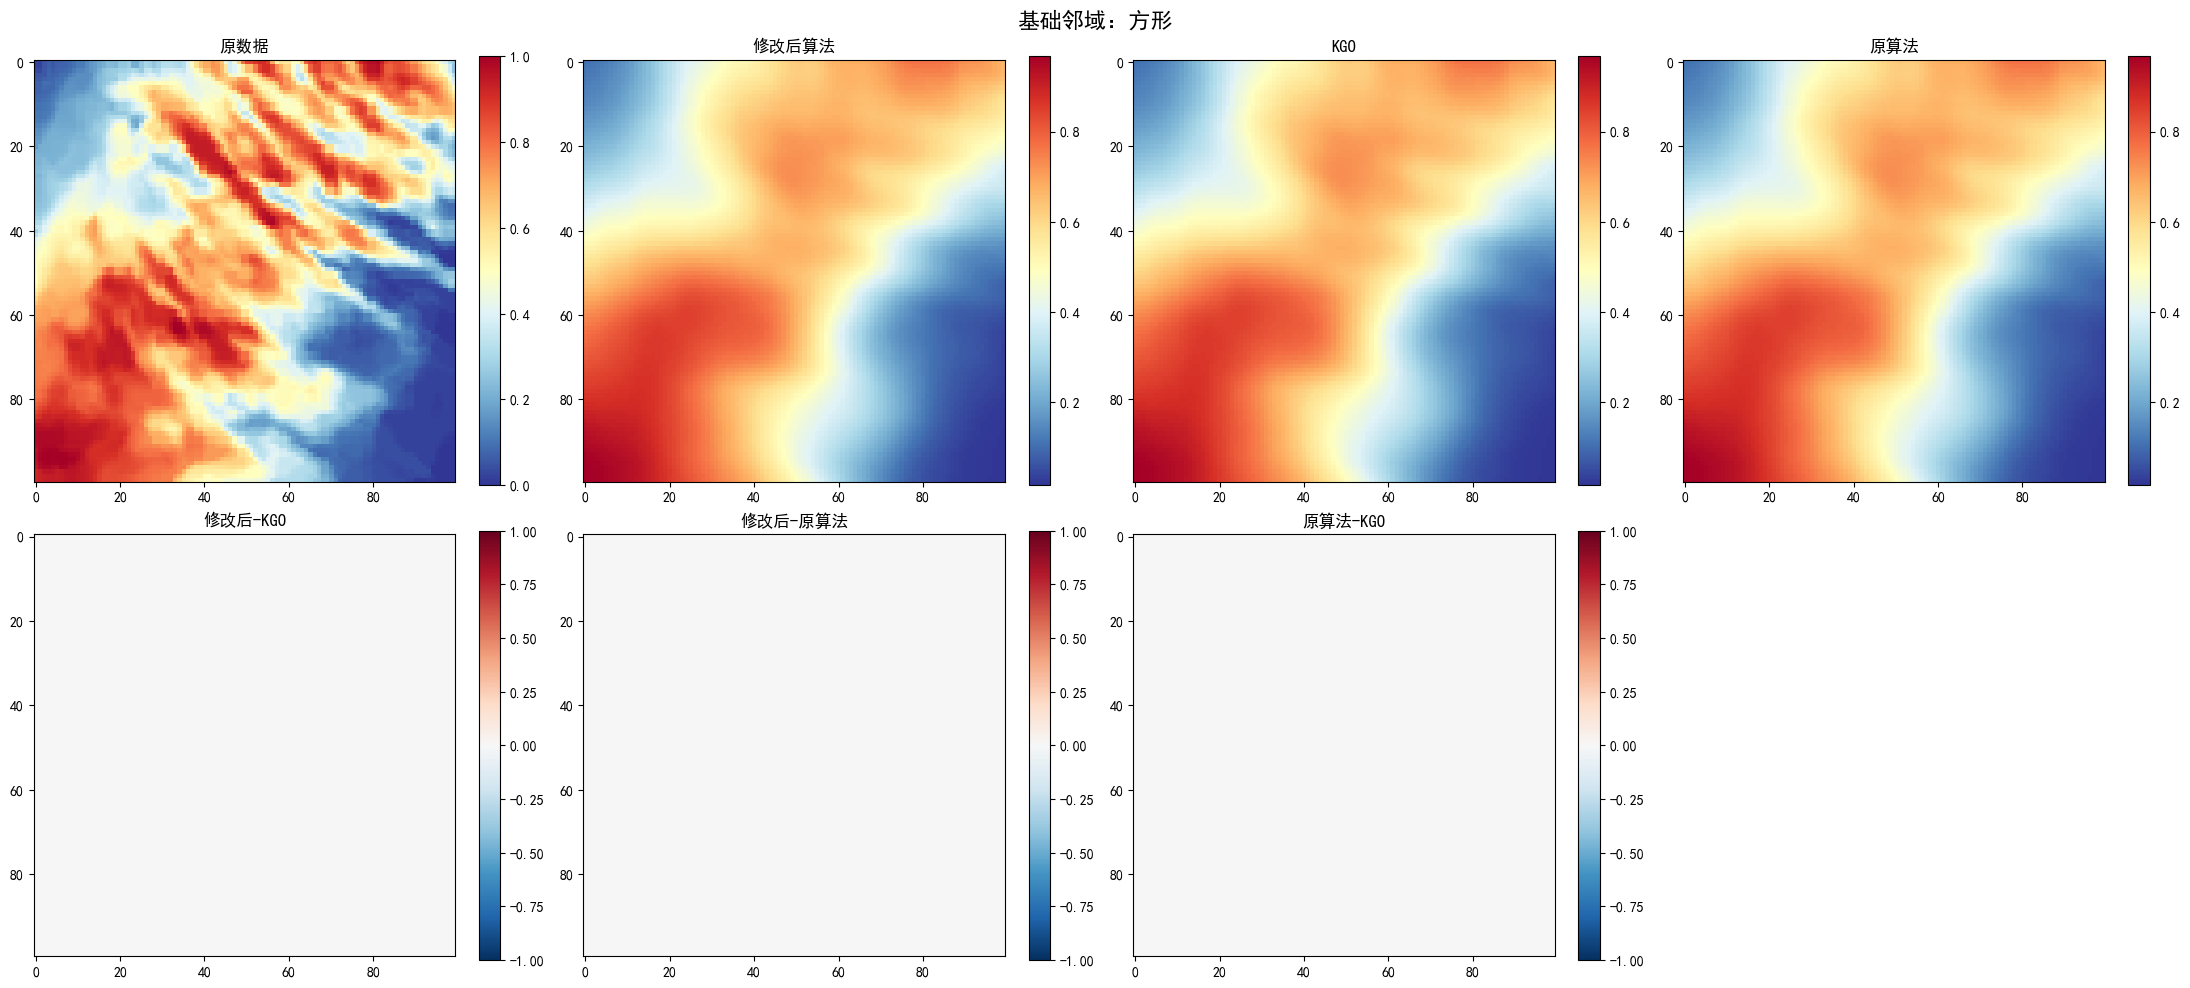

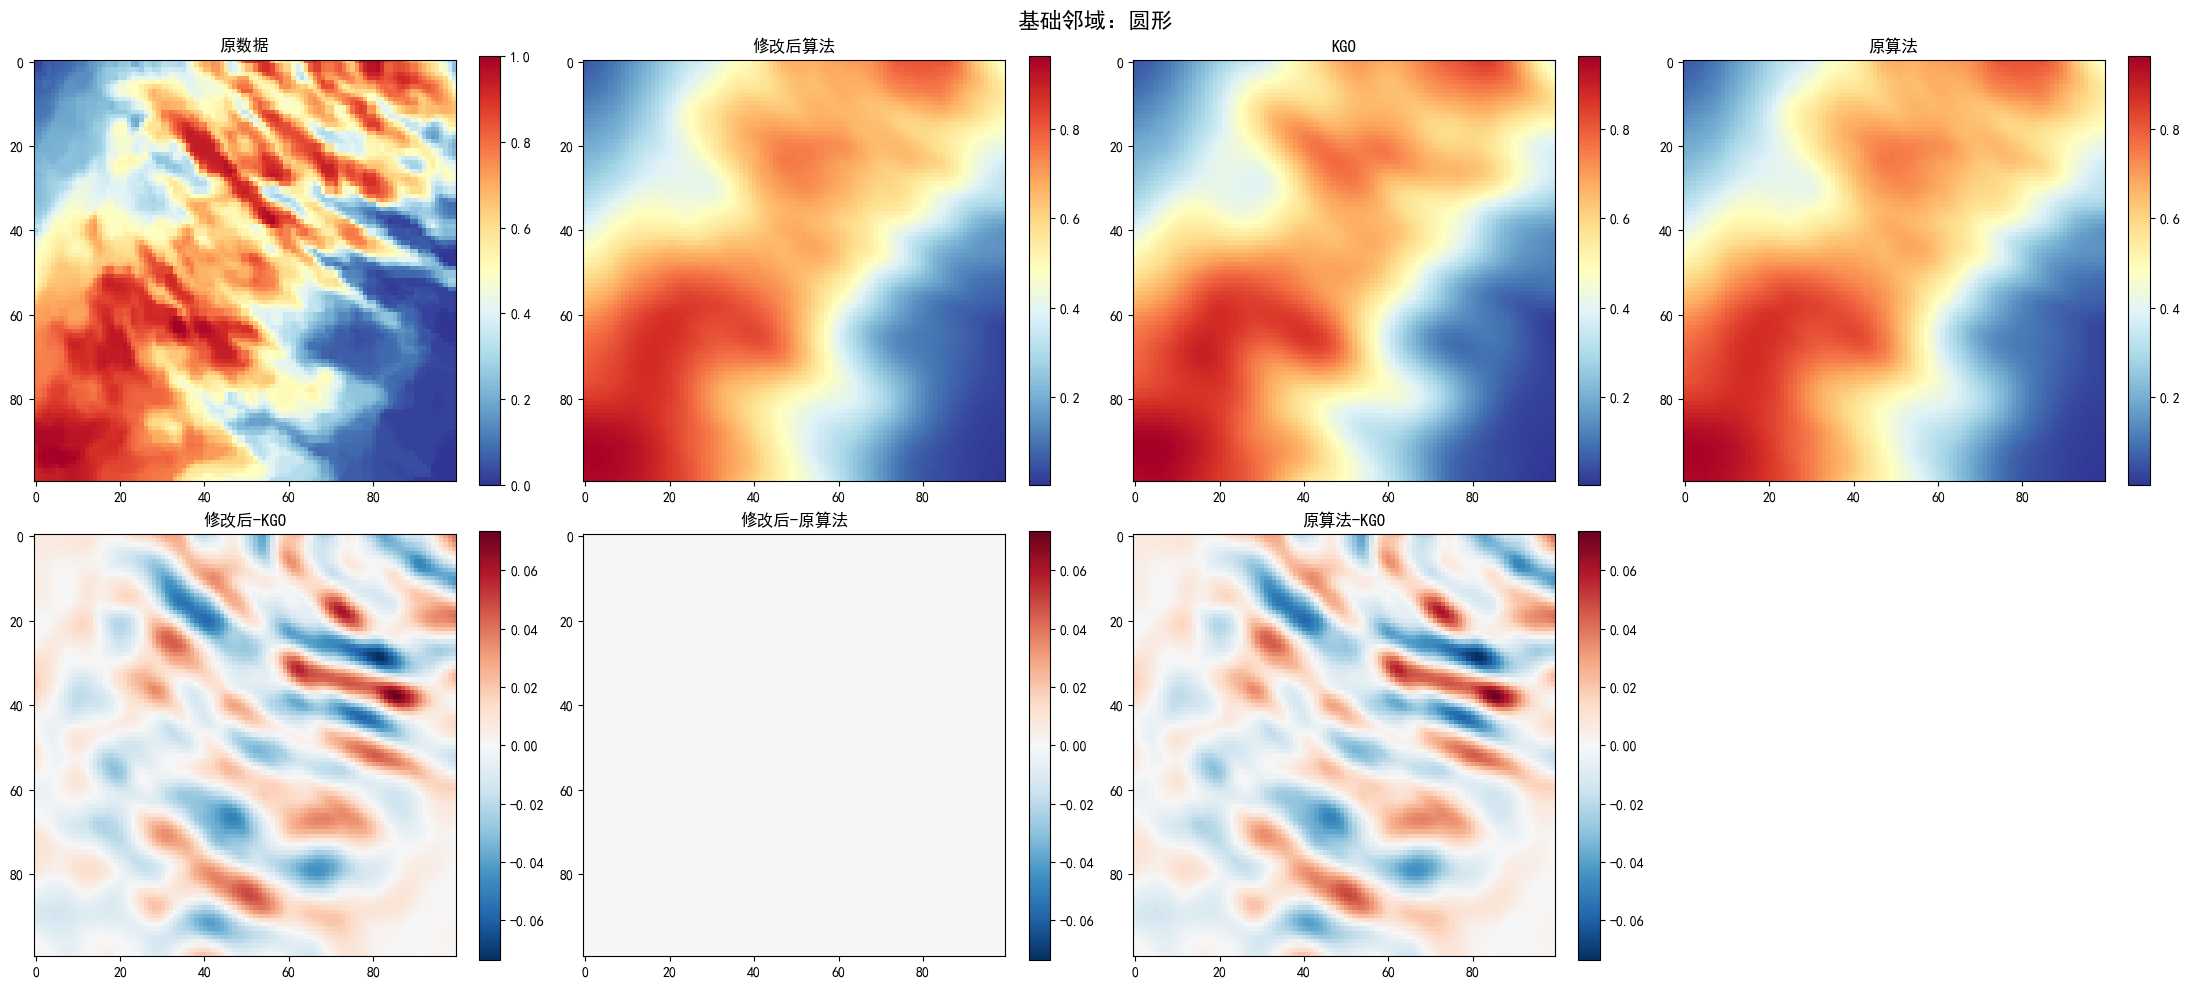

In [4]:
basic_dir = DATA_DIR / "basic"
member_index = 0

basic_square = NeighbourhoodProcessing("square", RADIUS_METRES).process(basic_input)
basic_circular = NeighbourhoodProcessing("circular", RADIUS_METRES).process(basic_input)

basic_kgo_square = load_primary_dataarray(basic_dir / "kgo_square.nc", PROB_VAR)
basic_kgo_circular = load_primary_dataarray(basic_dir / "kgo_circular.nc", PROB_VAR)
basic_original_square = load_primary_dataarray(basic_dir / "original_square.nc", PROB_VAR)
basic_original_circular = load_primary_dataarray(basic_dir / "original_circular.nc", PROB_VAR)

plot_basic(
    "基础邻域：方形",
    to_plot_2d(basic_input, member_index),
    to_plot_2d(basic_square, member_index),
    to_plot_2d(basic_kgo_square, member_index),
    to_plot_2d(basic_original_square, member_index),
)
plot_basic(
    "基础邻域：圆形",
    to_plot_2d(basic_input, member_index),
    to_plot_2d(basic_circular, member_index),
    to_plot_2d(basic_kgo_circular, member_index),
    to_plot_2d(basic_original_circular, member_index),
)


## 掩码邻域

掩码处理分两种情形验证：

- **外部掩码**：预处理已写出 `cli_input/mask/input.nc` 与 `cli_input/mask/mask.nc`；`mask=1` 为参与邻域的有效格点。
- **内部掩码**：预处理已写出 `cli_input/mask/input_masked.nc`（保留大填充值）；调用前转为 `MaskedArray`，以 `grid_spacing=2000 m` 走 numpy 路径。

因xr.DataArray输入无法携带内部掩码，故内部掩码验证使用MaskedArray作为输入。

输出语义（`re_mask=True`，对输出重掩码）：

- **外部掩码 + `DataArray`**：无效格点写为 `NaN`，有效格点为邻域统计结果；`NaN` 可直接交给 `meteva_base.write_griddata_to_nc`（量化为哨兵、读回可还原）。对比时仅在有效格点比数值。
- **内部掩码 + `MaskedArray`**：返回 `MaskedArray`，无效位以 `mask` 标记（底层 `.data` 仍是邻域统计值），与原方法一致。
- 官方 KGO nc 中掩码位常为 `NaN`，故下图对比均在有效格点上进行。


### 外部掩码

使用预处理得到的 `mask_input` 与 `mask_external`，调用 `process(mask_input, mask=mask_external)`。掩码图为 **0/1 离散色标**：`1` = 参与，`0` = 不参与。


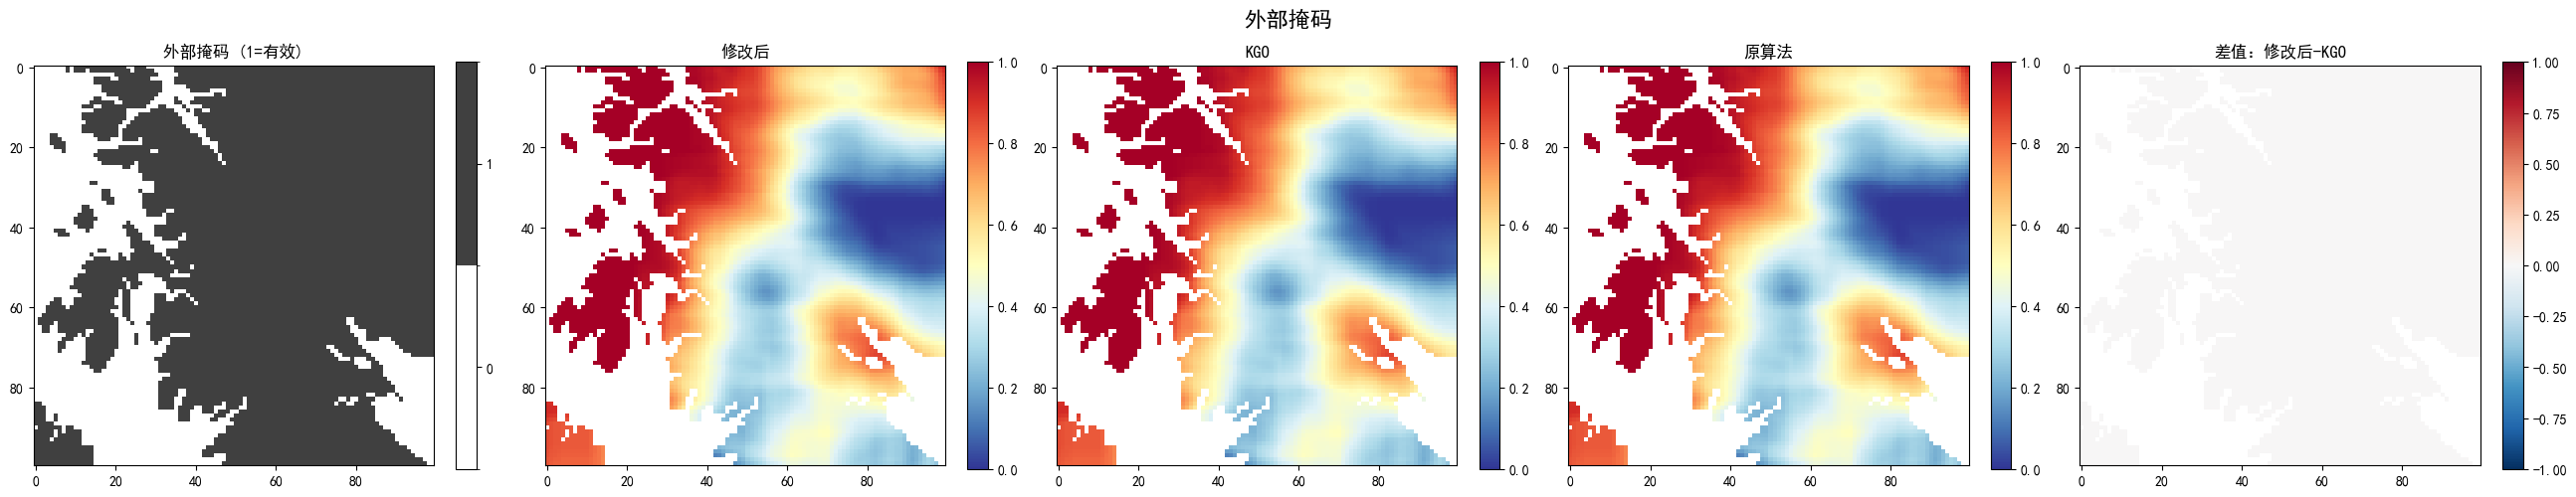

In [5]:
mask_dir = DATA_DIR / "mask"

mask_modified_external = NeighbourhoodProcessing("square", RADIUS_METRES).process(mask_input, mask=mask_external)

external_participate = to_plot_2d(mask_external, 0) == 1
external_mask_01 = external_participate.astype(np.uint8)
plot_mask(
    "外部掩码",
    external_mask_01,
    np.ma.masked_where(~external_participate, to_plot_2d(mask_modified_external, 0)),
    np.ma.masked_where(
        ~external_participate,
        to_plot_2d(load_primary_dataarray(mask_dir / "kgo_external_masked.nc", PROB_VAR), 0),
    ),
    np.ma.masked_where(
        ~external_participate,
        to_plot_2d(load_primary_dataarray(mask_dir / "original_external_masked.nc", PROB_VAR), 0),
    ),
    cover_label="外部掩码 (1=有效)",
)


### 内部掩码

将 `mask_internal_input` 转为 `MaskedArray` 后调用 `process(..., grid_spacing=2000)`。掩码图为 **0/1 离散色标**：`1` = 内部掩码无效格点（`mask=True`），`0` = 有效。


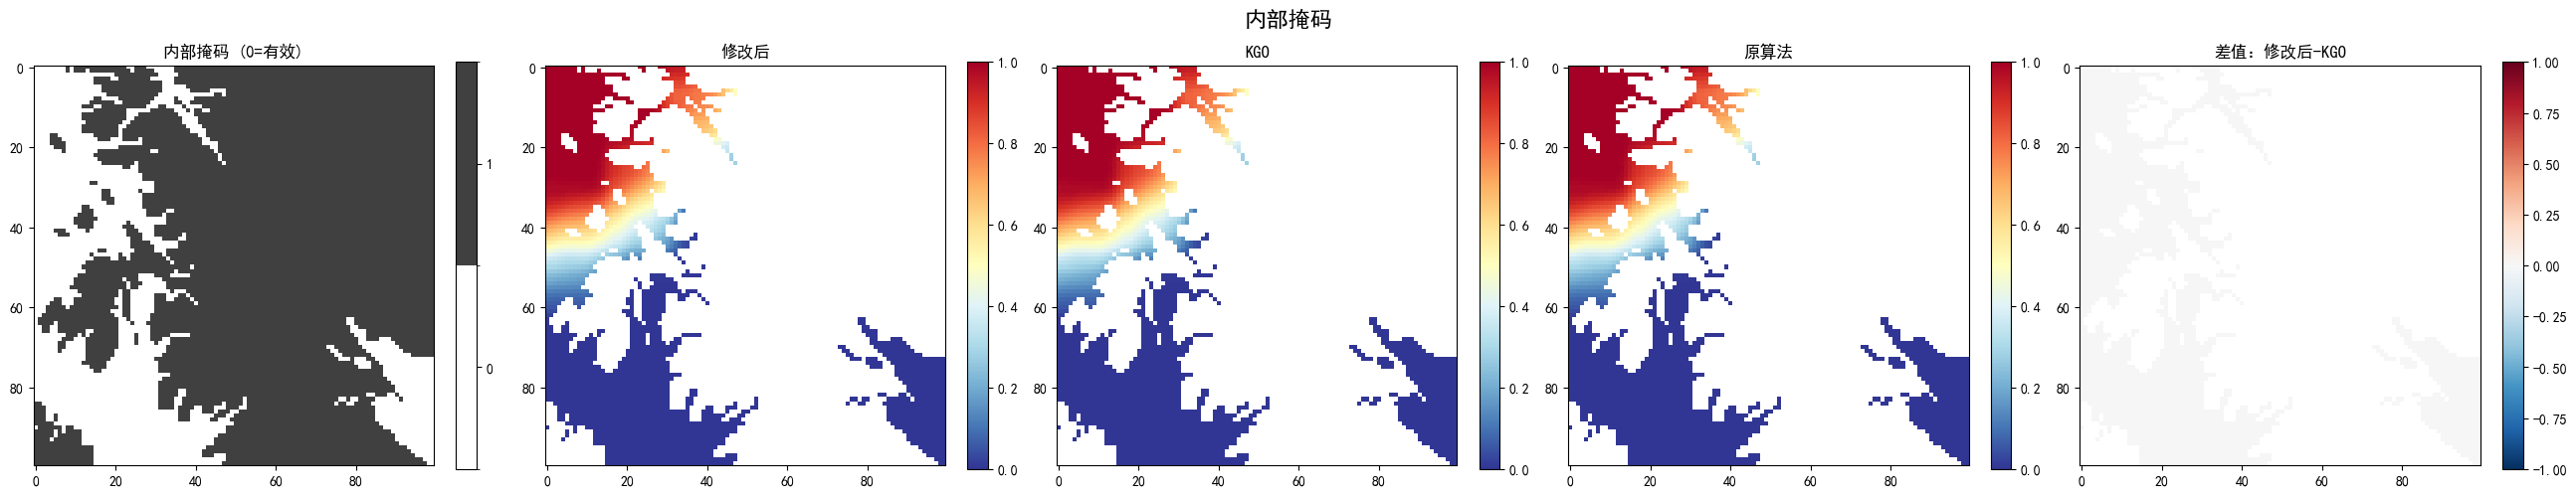

In [6]:
mask_dir = DATA_DIR / "mask"
GRID_SPACING_METRES = 2000.0

#输入为MaskedArray类型
internal_masked = mask_fill_values_array(mask_internal_input)
internal_missing = np.ma.getmaskarray(to_plot_2d(internal_masked, 0))
internal_mask_01 = internal_missing.astype(np.uint8)

masked_modified_ma = NeighbourhoodProcessing("square", RADIUS_METRES).process(
    internal_masked,
    grid_spacing=GRID_SPACING_METRES,
)
modified_slice = np.ma.asarray(to_plot_2d(masked_modified_ma, 0))
plot_mask(
    "内部掩码",
    internal_mask_01,
    np.ma.masked_where(internal_missing, modified_slice),
    np.ma.masked_where(
        internal_missing,
        masked_values(
            to_plot_2d(
                load_primary_dataarray(mask_dir / "kgo_masked.nc", PROB_VAR, mask_and_scale=False),
                0,
            )
        ),
    ),
    np.ma.masked_where(
        internal_missing,
        masked_values(
            to_plot_2d(
                load_primary_dataarray(mask_dir / "original_masked.nc", PROB_VAR, mask_and_scale=False),
                0,
            )
        ),
    ),
    cover_label="内部掩码 (0=有效)",
)


## 百分位验证

圆形邻域百分位输出，对比 KGO 与原算法。


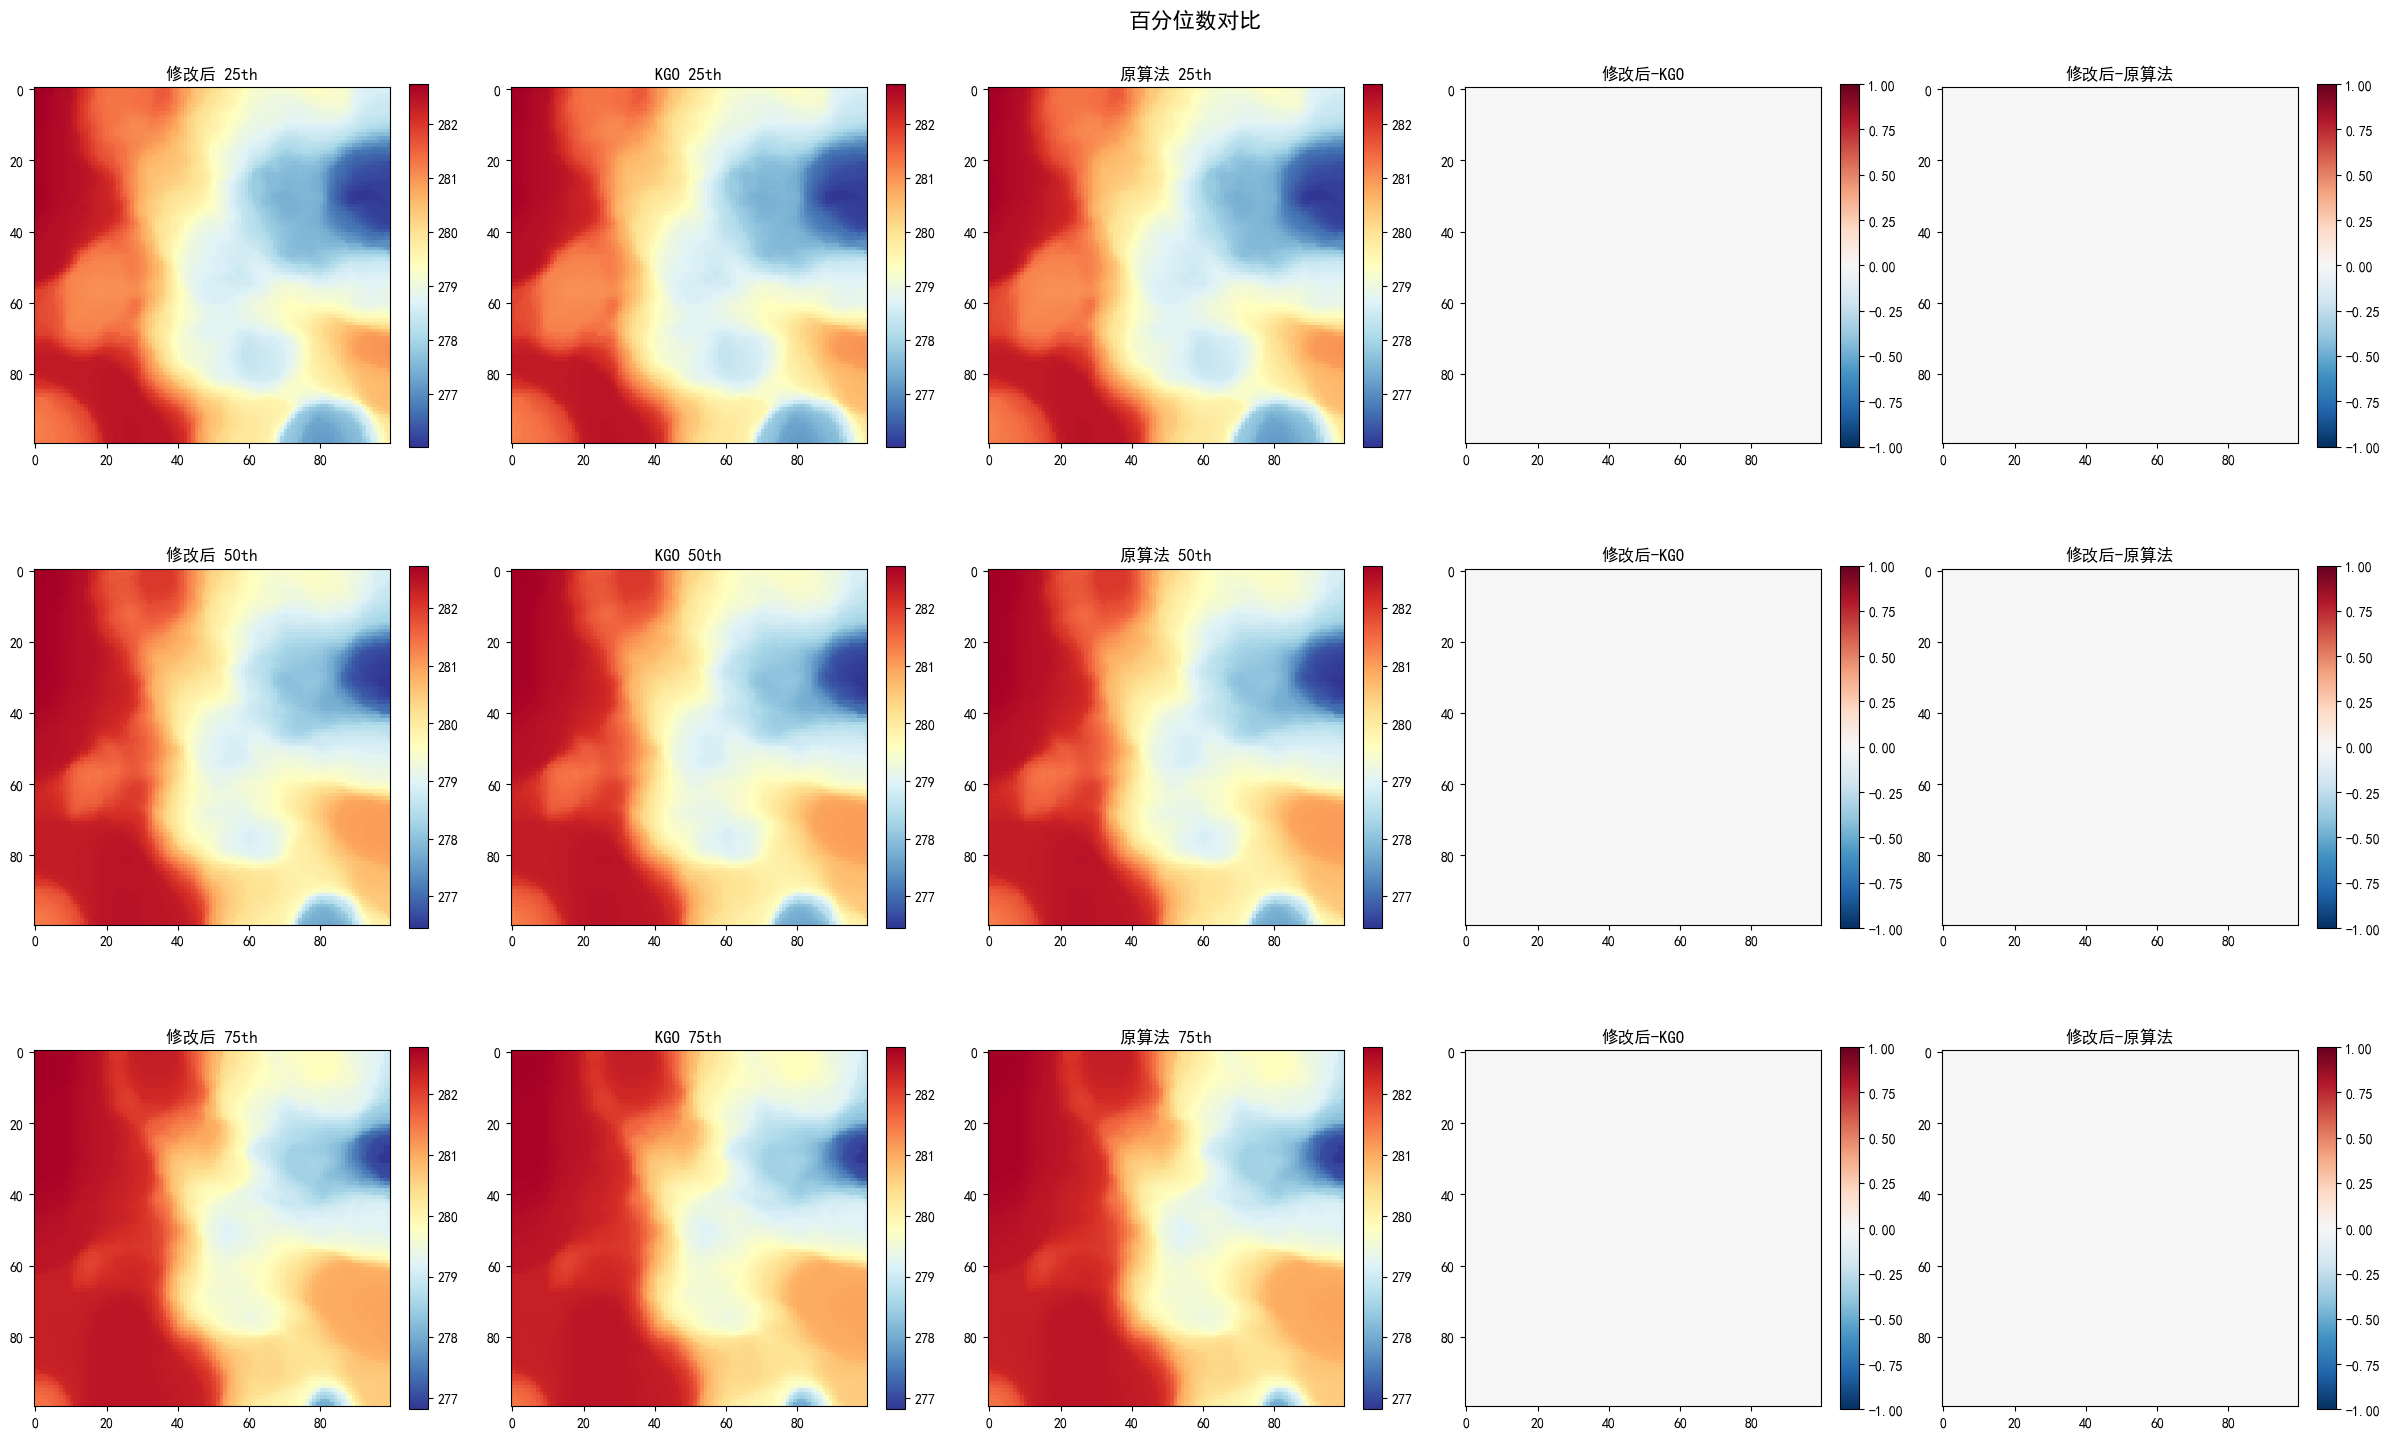

In [7]:
pct_dir = DATA_DIR / "percentile"

pct_modified = GeneratePercentilesFromANeighbourhood(
    RADIUS_METRES,
    percentiles=PERCENTILES,
).process(pct_input)
pct_kgo = load_primary_dataarray(pct_dir / "kgo_circular_percentile.nc", TEMP_VAR)
pct_original = load_primary_dataarray(pct_dir / "original_circular_percentile.nc", TEMP_VAR)

fig, axes = plt.subplots(len(PERCENTILES), 5, figsize=(24, 5 * len(PERCENTILES)), squeeze=False)
for row, pct in enumerate(PERCENTILES):
    m = to_percentile_2d(pct_modified, pct, prefer_realization_index=0)
    k = to_percentile_2d(pct_kgo, pct, prefer_realization_index=0)
    o = to_percentile_2d(pct_original, pct, prefer_realization_index=0)
    vmin, vmax = common_limits(m, k, o)
    diff_mk, diff_mo = m - k, m - o
    norm = diff_norm(diff_mk, diff_mo)
    for ax, data, name in [
        (axes[row, 0], m, f"修改后 {pct:.0f}th"),
        (axes[row, 1], k, f"KGO {pct:.0f}th"),
        (axes[row, 2], o, f"原算法 {pct:.0f}th"),
    ]:
        im = ax.imshow(data, cmap="RdYlBu_r", vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)
    for ax, data, name in [
        (axes[row, 3], diff_mk, "修改后-KGO"),
        (axes[row, 4], diff_mo, "修改后-原算法"),
    ]:
        im = ax.imshow(data, cmap="RdBu_r", norm=norm, interpolation="nearest")
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("百分位数对比", fontsize=16)
fig.tight_layout()
plt.show()


In [8]:
pct_modified

<xarray.DataArray 'air_temperature' (member: 12, level: 1, time: 1, dtime: 1,
                                     lat: 100, lon: 100)> Size: 480kB
array([[[[[[282.72955, 282.71686, 282.70816, ..., 278.65   ,
            278.65   , 278.65   ],
           [282.71967, 282.7116 , 282.70474, ..., 278.6311 ,
            278.6311 , 278.6267 ],
           [282.71686, 282.70816, 282.70346, ..., 278.5644 ,
            278.5644 , 278.5644 ],
           ...,
           [281.18338, 281.1882 , 281.20508, ..., 279.45123,
            279.58145, 279.79102],
           [281.19818, 281.19818, 281.21866, ..., 279.2789 ,
            279.58145, 279.79102],
           [281.22113, 281.22113, 281.242  , ..., 279.2789 ,
            279.45123, 279.61548]]]]],




       [[[[[282.74323, 282.74323, 282.74323, ..., 278.8587 ,
            278.8587 , 278.8587 ],
           [282.74323, 282.74323, 282.74323, ..., 278.8587 ,
...
           [281.419  , 281.419  , 281.4522 , ..., 279.8724 ,
            279.8724 , 279.95795]]]]],




       [[[[[282.70773, 282.70773, 282.70486, ..., 279.38736,
            279.22458, 279.18597],
           [282.70773, 282.70486, 282.70486, ..., 279.35855,
            279.22458, 279.18597],
           [282.70486, 282.70486, 282.70486, ..., 279.32544,
            279.22458, 279.18597],
           ...,
           [281.6515 , 281.654  , 281.68082, ..., 280.63266,
            280.6508 , 280.6508 ],
           [281.6271 , 281.64337, 281.654  , ..., 280.63266,
            280.6468 , 280.6508 ],
           [281.61484, 281.61484, 281.64337, ..., 280.62924,
            280.62924, 280.62924]]]]]],
      shape=(12, 1, 1, 1, 100, 100), dtype=float32)
Coordinates:
  * member               (member) int32 48B 0 1 2 3 4 5 6 7 8 9 10 11
    member_input_member  (member) object 96B '0' '0' '0' '14' ... '20' '20' '20'
    member_percentile    (member) float32 48B 25.0 50.0 75.0 ... 25.0 50.0 75.0
  * level                (level) float32 4B 0.0
  * time                 (time) datetime64[ns] 8B 1970-01-01
  * dtime                (dtime) int32 4B 0
  * lat                  (lat) float32 400B 1.64e+05 1.66e+05 ... 3.62e+05
  * lon                  (lon) float32 400B -2.58e+05 -2.56e+05 ... -6e+04
Attributes:
    units:               K
    model:               
    dtime_units:         hour
    level_type:          isobaric
    time_type:           UT
    time_bounds:         [0, 0]
    grid_mapping_attrs:  {"grid_mapping_name": "lambert_azimuthal_equal_area"...
    member_is_stacked:   True
    member_stack_dims:   member,percentile
    member_units:        %

## CLI 验证

CLI 从 `cli_input/` 读取预处理输入，结果写出到 `cli_output/`。示例脚本 `neighbourhood_probability_processing/cli/ens_nbhood.py` 对应**基础方形**场景。

各小节给出 `process()` 调用示例，保存 CLI 结果后与 KGO、原 IMPROVER CLI 参考输出做三图对比（不绘制差异图）。KGO 与原 CLI 自 `test_data/official_test_nbhood/{basic,mask,percentile}/` 读取。


### 基础方形

`cli_input/basic/input.nc` → 方形邻域概率输出。

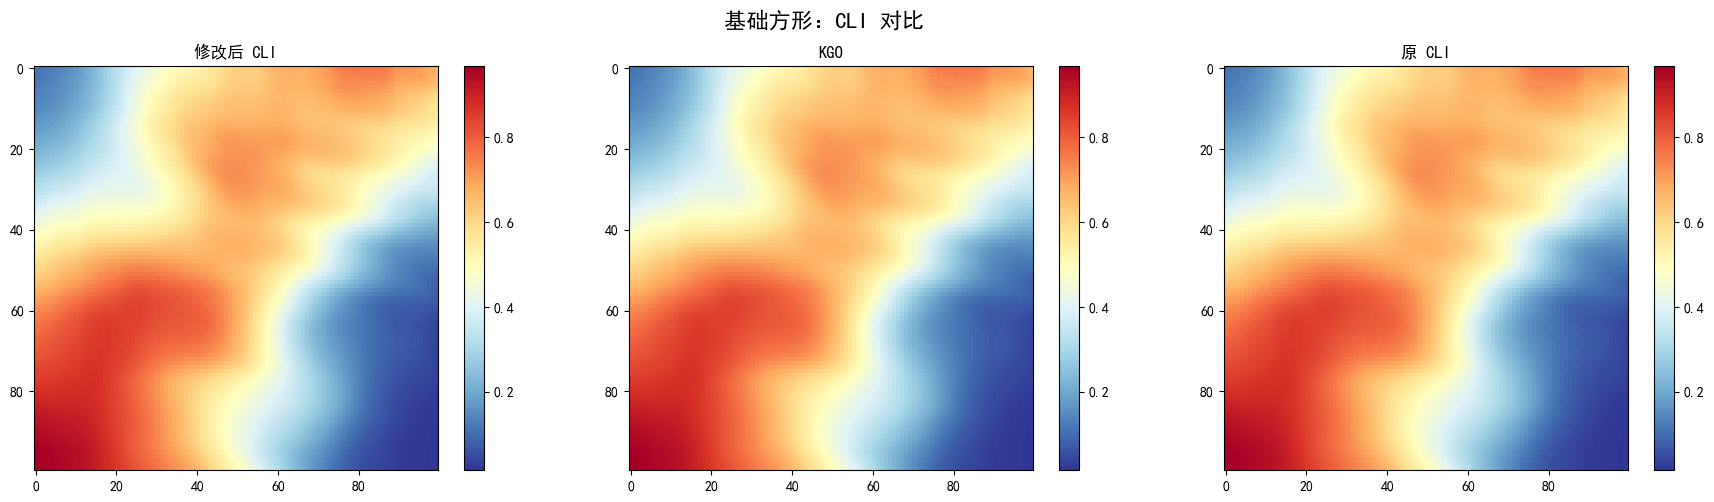

In [9]:
CLI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
from neighbourhood_probability_processing.cli.ens_nbhood import process

out = CLI_OUTPUT_DIR / "cli_nbhood_square_result.nc"
process(
    str(CLI_INPUT_DIR / "basic" / "input.nc"),
    "probabilities",
    [RADIUS_METRES],
    output_path=str(out),
    neighbourhood_shape="square",
)
cli_da = load_cli_result_dataarray(out, PROB_VAR)
kgo_da = load_primary_dataarray(DATA_DIR / "basic" / "kgo_square.nc", PROB_VAR)
org_da = load_primary_dataarray(DATA_DIR / "basic" / "cli_square_result.nc", PROB_VAR)
plot_cli_triplet("基础方形：CLI 对比", cli_da, kgo_da, org_da, member_index=0)


### 基础圆形

`cli_input/basic/input.nc` → 圆形邻域概率输出。

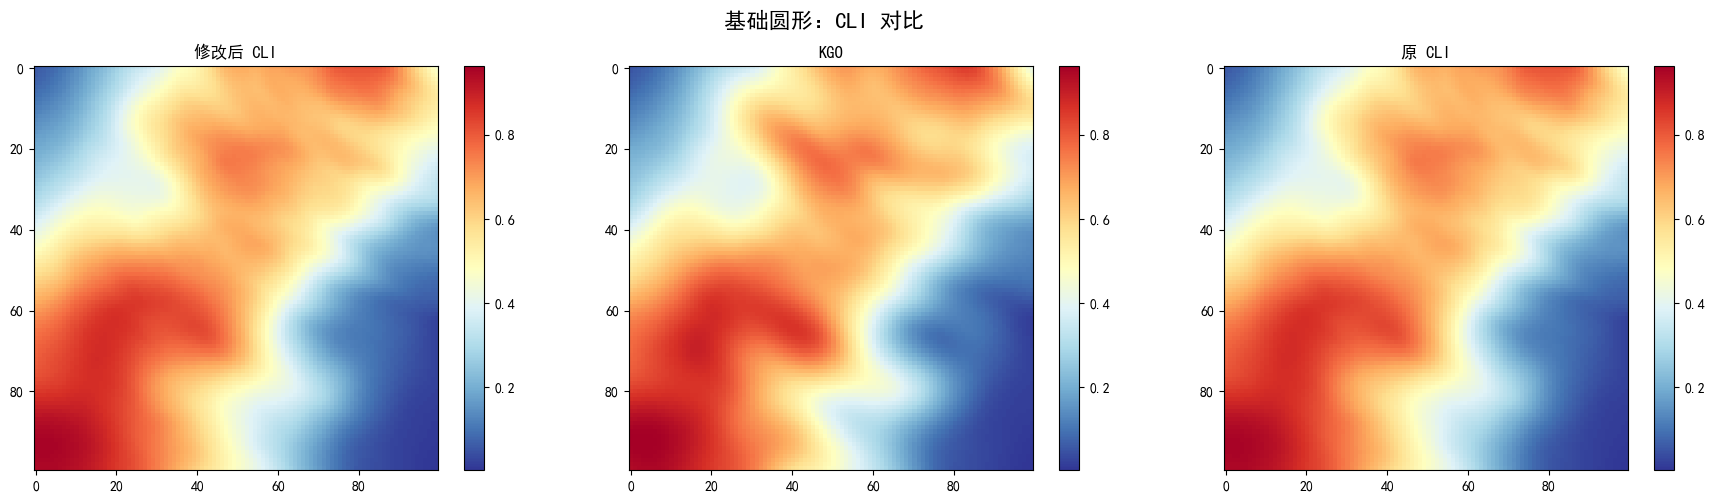

In [10]:
out = CLI_OUTPUT_DIR / "cli_nbhood_circular_result.nc"
process(
    str(CLI_INPUT_DIR / "basic" / "input.nc"),
    "probabilities",
    [RADIUS_METRES],
    output_path=str(out),
    neighbourhood_shape="circular",
)
cli_da = load_cli_result_dataarray(out, PROB_VAR)
kgo_da = load_primary_dataarray(DATA_DIR / "basic" / "kgo_circular.nc", PROB_VAR)
org_da = load_primary_dataarray(DATA_DIR / "basic" / "cli_circular_result.nc", PROB_VAR)
plot_cli_triplet("基础圆形：CLI 对比", cli_da, kgo_da, org_da, member_index=0)


### 外部掩码

`cli_input/mask/input.nc` + `mask.nc` → 外部掩码邻域输出。

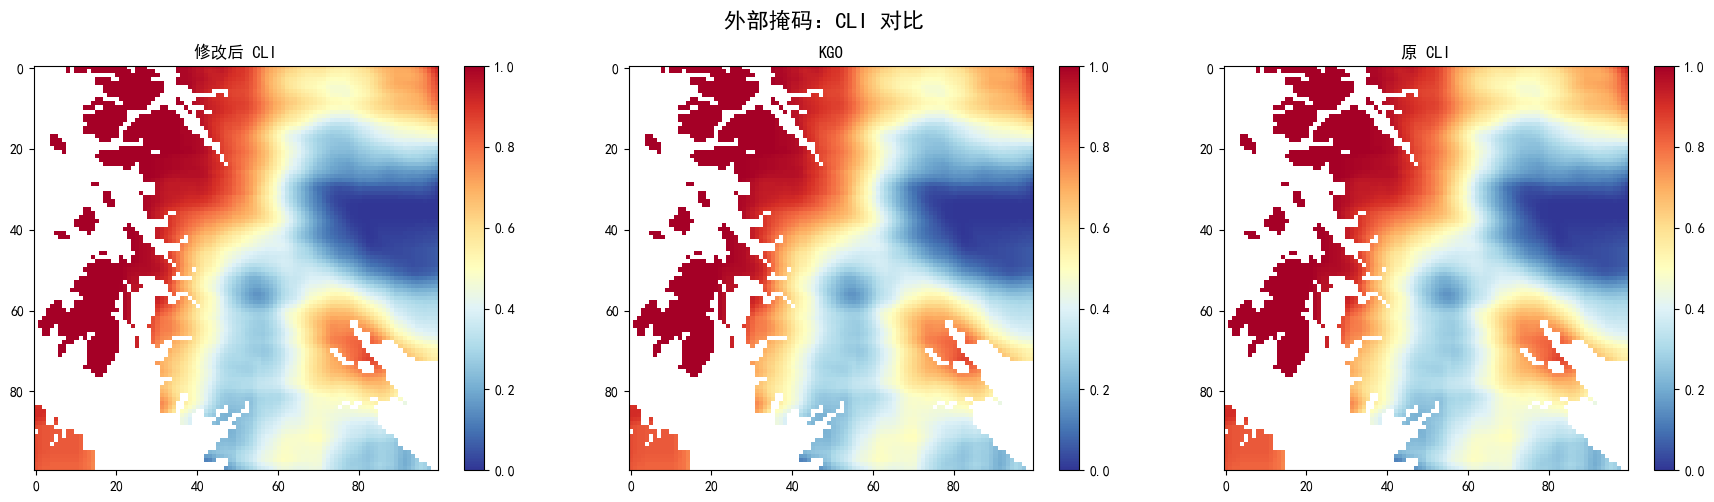

In [11]:
out = CLI_OUTPUT_DIR / "cli_nbhood_external_masked_result.nc"
process(
    str(CLI_INPUT_DIR / "mask" / "input.nc"),
    "probabilities",
    [RADIUS_METRES],
    mask_path=str(CLI_INPUT_DIR / "mask" / "mask.nc"),
    output_path=str(out),
    neighbourhood_shape="square",
)
cli_da = load_cli_result_dataarray(out, PROB_VAR)
kgo_da = load_primary_dataarray(DATA_DIR / "mask" / "kgo_external_masked.nc", PROB_VAR)
org_da = load_primary_dataarray(DATA_DIR / "mask" / "cli_external_masked_result.nc", PROB_VAR)
plot_cli_triplet("外部掩码：CLI 对比", cli_da, kgo_da, org_da, member_index=0)


### 百分位

`cli_input/percentile/input_circular_percentile.nc` → 圆形邻域百分位输出。

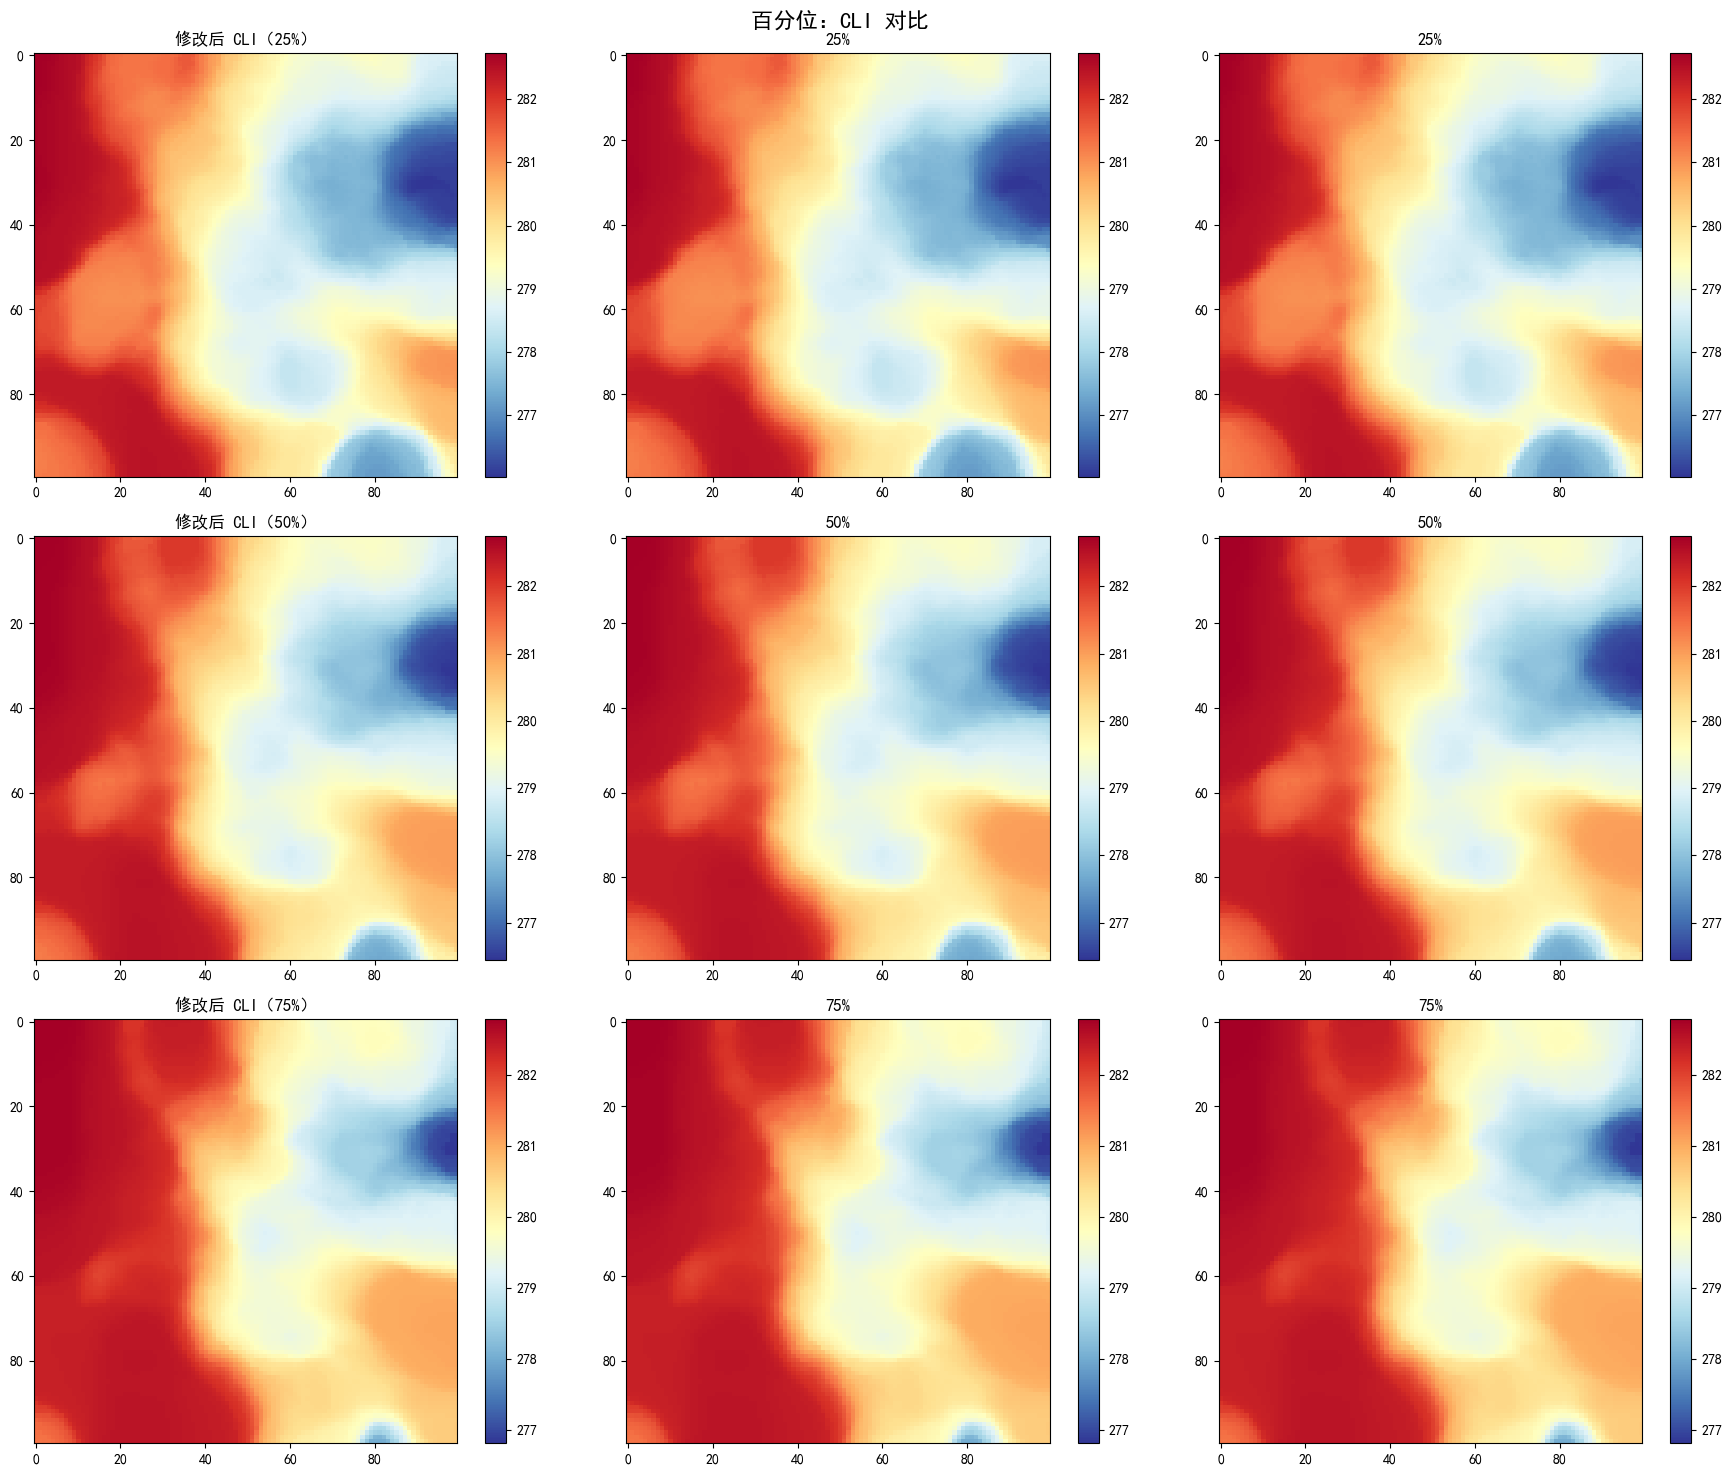

In [12]:
out = CLI_OUTPUT_DIR / "cli_nbhood_percentiles.nc"
process(
    str(CLI_INPUT_DIR / "percentile" / "input_circular_percentile.nc"),
    "percentiles",
    [RADIUS_METRES],
    percentiles=PERCENTILES,
    output_path=str(out),
    neighbourhood_shape="circular",
)
cli_da = load_cli_result_dataarray(out, TEMP_VAR)
kgo_da = load_primary_dataarray(DATA_DIR / "percentile" / "kgo_circular_percentile.nc", TEMP_VAR)
org_da = load_primary_dataarray(
    DATA_DIR / "percentile" / "cli_circular_percentile_result.nc", TEMP_VAR
)
plot_cli_percentile_triplet("百分位：CLI 对比", cli_da, kgo_da, org_da)
